# EDA Lab - Step 1

Dataset selected: **UCI Adult Income** (from Awesome Public Datasets / UCI ML Repository).

Why this fits:
- More than 30 rows (32,561 rows)
- 8+ columns (14 columns)
- 5+ numerical columns (`age`, `fnlwgt`, `education_num`, `capital_gain`, `capital_loss`, `hours_per_week`)
- Includes categorical columns for later categorical analysis

In [6]:
import pandas as pd

# UCI Adult Income dataset (public, beginner-friendly for EDA)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
    "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
    "hours_per_week", "native_country", "income"
]

df = pd.read_csv(url, names=columns, na_values=" ?", skipinitialspace=True)

print("Rows, Columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isna().sum())

numeric_cols = df.select_dtypes(include="number").columns.tolist()
print("\nNumeric columns:", numeric_cols)
print("Count of numeric columns:", len(numeric_cols))

Rows, Columns: (32561, 15)

Column names:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

Data types:
age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

First 5 rows:
   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338

## Step 2

Univariate EDA for all variables (beginner NIST style):
- Numeric variables: histogram + min, max, mean, median, outlier count (IQR rule)
- Categorical variables: bar chart of value counts + unique count + mode

Numeric columns: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical columns: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']

=== Numeric: age ===
min=17, max=90, mean=38.58, median=37.00
outliers (IQR rule)=143


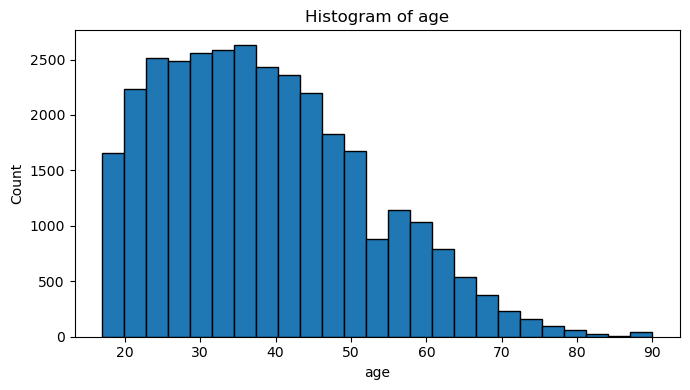


=== Numeric: fnlwgt ===
min=12285, max=1484705, mean=189778.37, median=178356.00
outliers (IQR rule)=992


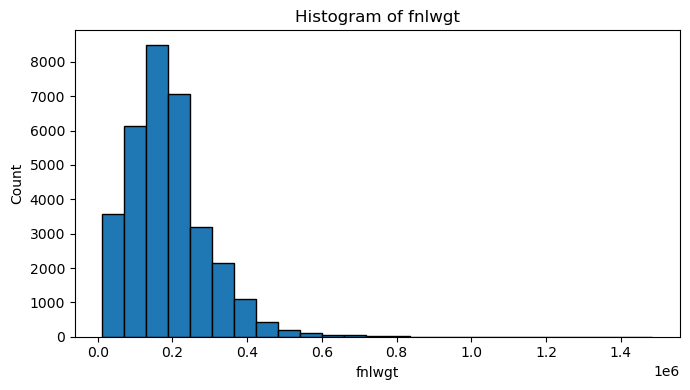


=== Numeric: education_num ===
min=1, max=16, mean=10.08, median=10.00
outliers (IQR rule)=1198


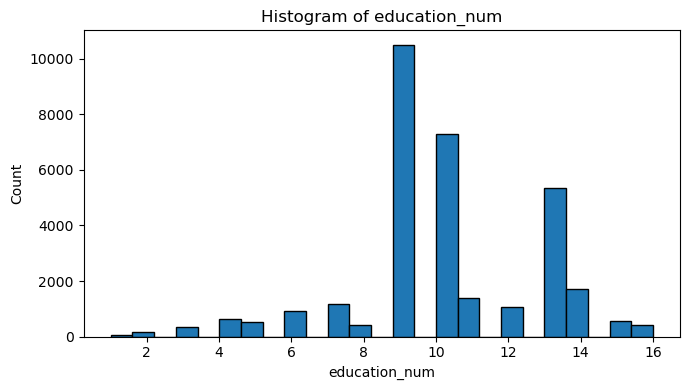


=== Numeric: capital_gain ===
min=0, max=99999, mean=1077.65, median=0.00
outliers (IQR rule)=2712


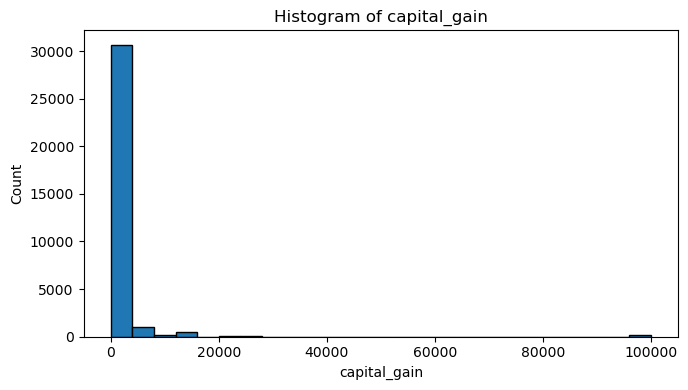


=== Numeric: capital_loss ===
min=0, max=4356, mean=87.30, median=0.00
outliers (IQR rule)=1519


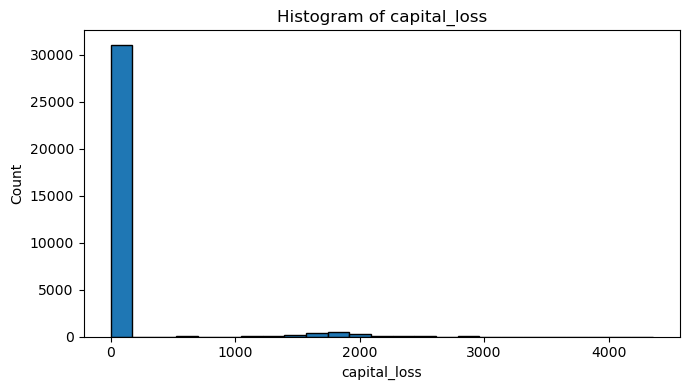


=== Numeric: hours_per_week ===
min=1, max=99, mean=40.44, median=40.00
outliers (IQR rule)=9008


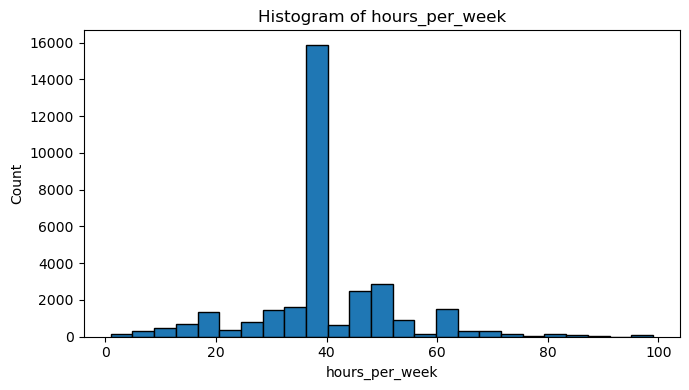


=== Categorical: workclass ===
unique values=9
mode=Private (count=22696)


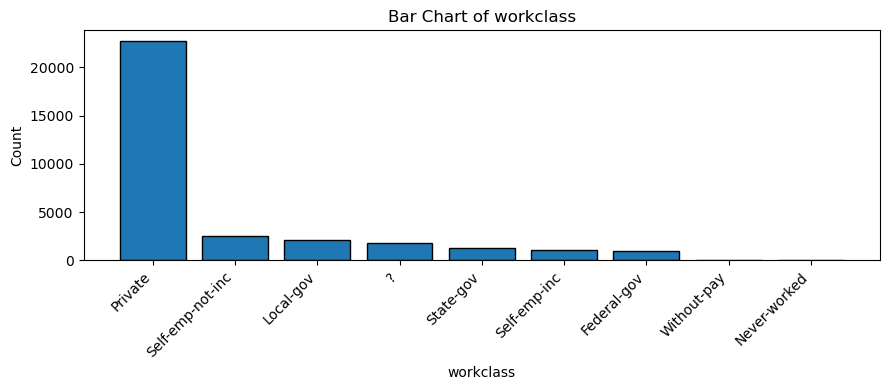


=== Categorical: education ===
unique values=16
mode=HS-grad (count=10501)


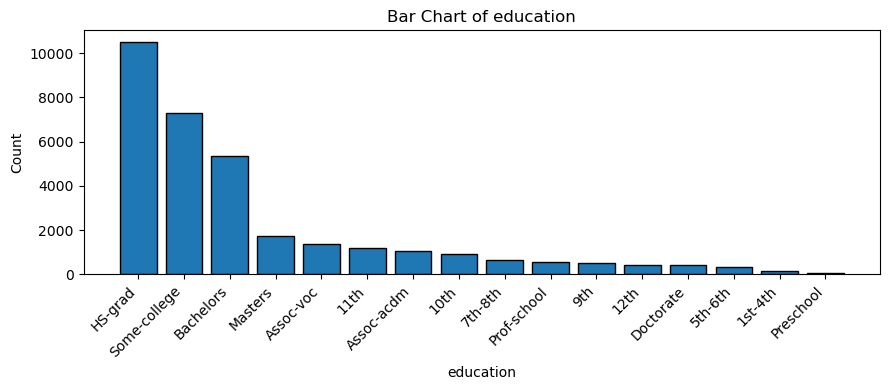


=== Categorical: marital_status ===
unique values=7
mode=Married-civ-spouse (count=14976)


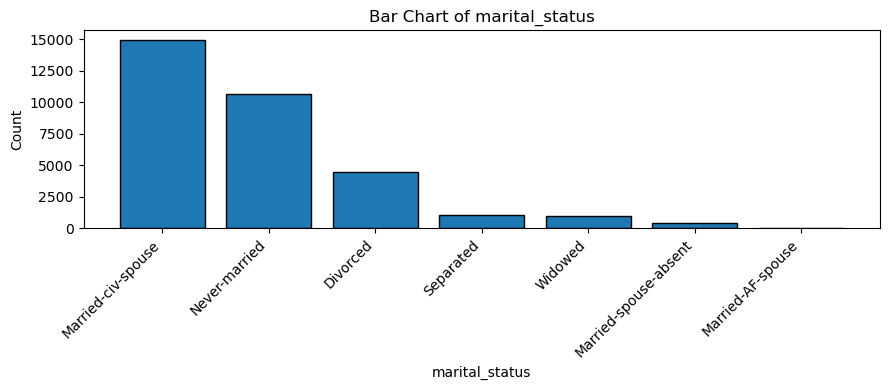


=== Categorical: occupation ===
unique values=15
mode=Prof-specialty (count=4140)


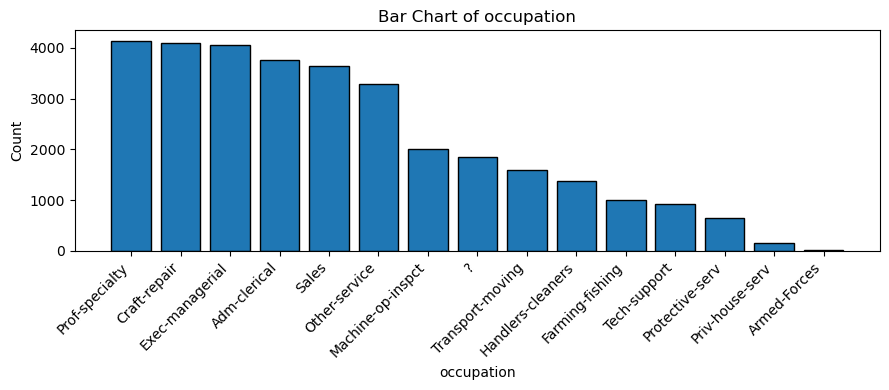


=== Categorical: relationship ===
unique values=6
mode=Husband (count=13193)


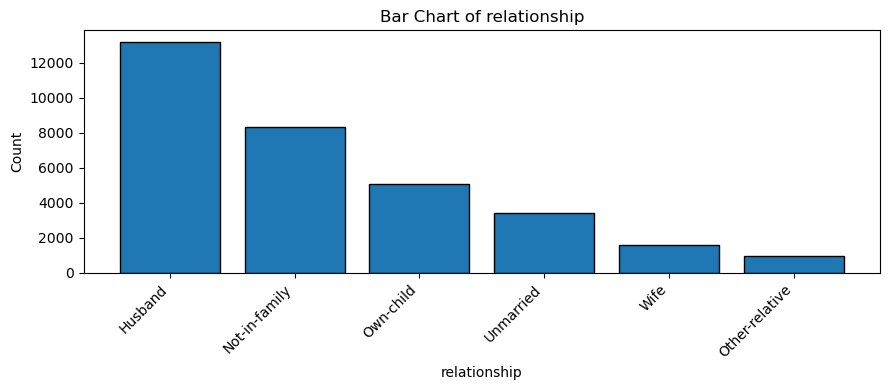


=== Categorical: race ===
unique values=5
mode=White (count=27816)


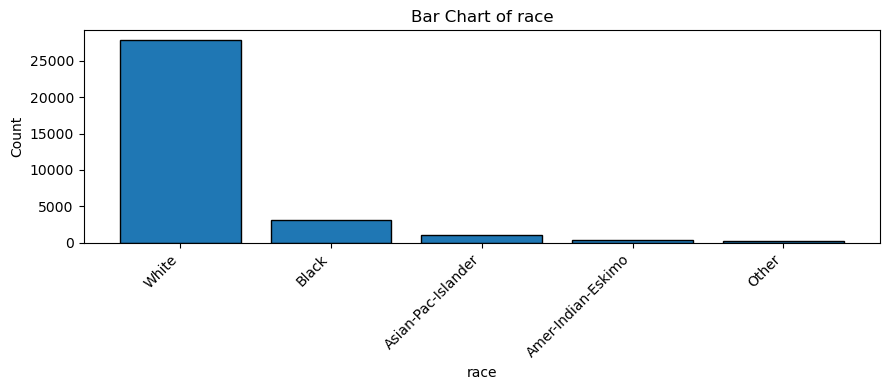


=== Categorical: sex ===
unique values=2
mode=Male (count=21790)


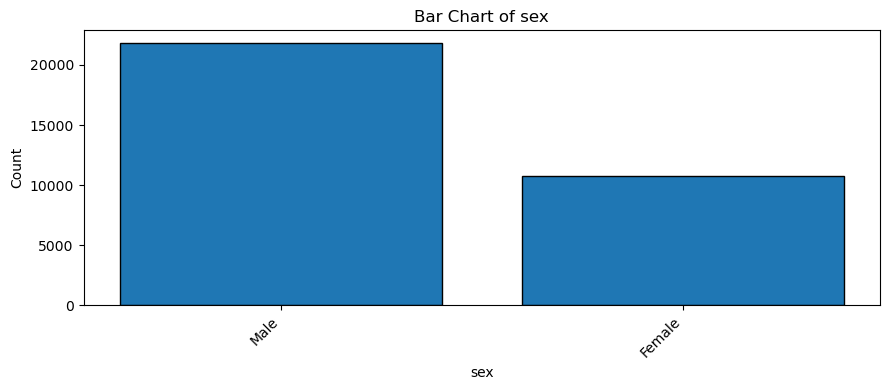


=== Categorical: native_country ===
unique values=42
mode=United-States (count=29170)


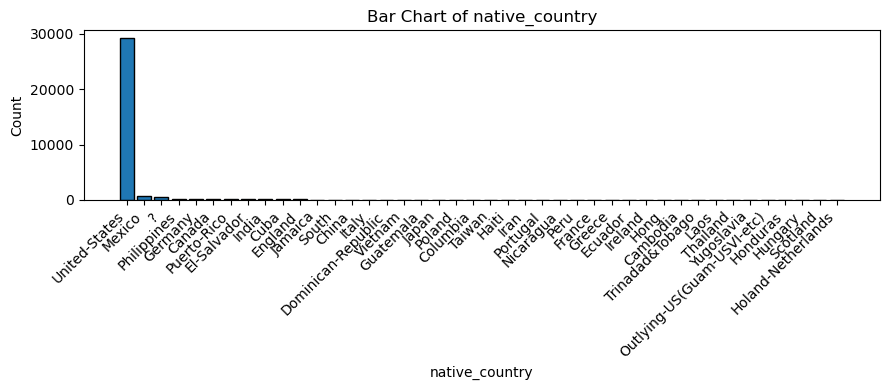


=== Categorical: income ===
unique values=2
mode=<=50K (count=24720)


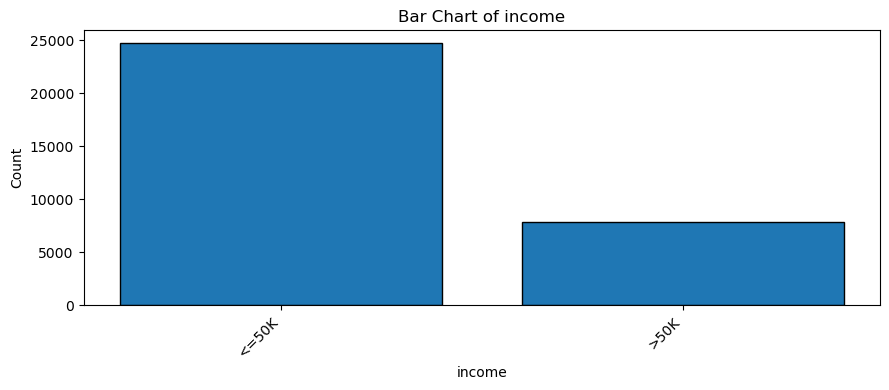

In [7]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = [col for col in df.columns if col not in numeric_cols]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Numeric: histogram + summary statistics + IQR outlier count
for col in numeric_cols:
    s = df[col].dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((s < lower) | (s > upper)).sum()

    print(f"\n=== Numeric: {col} ===")
    print(f"min={s.min()}, max={s.max()}, mean={s.mean():.2f}, median={s.median():.2f}")
    print(f"outliers (IQR rule)={outlier_count}")

    plt.figure(figsize=(7, 4))
    plt.hist(s, bins=25, edgecolor="black")
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Categorical: bar chart + quick counts
for col in categorical_cols:
    counts = df[col].astype(str).value_counts(dropna=False)

    print(f"\n=== Categorical: {col} ===")
    print(f"unique values={counts.shape[0]}")
    print(f"mode={counts.index[0]} (count={counts.iloc[0]})")

    plt.figure(figsize=(9, 4))
    plt.bar(counts.index.astype(str), counts.values, edgecolor="black")
    plt.title(f"Bar Chart of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()